In [1]:
import numpy as np
import pandas as pd

In [2]:
import glob, os
def build_lstm_table(folder_path, freq="60min"):
    all_records = []

    for file in glob.glob(os.path.join(folder_path, "*.txt")):
        df = pd.read_csv(file, names=["Time", "Parameter", "Value"])
        df["Time"] = pd.to_datetime(df["Time"].astype(str).str.strip(), format="%H:%M", errors="coerce")
        df = df.dropna(subset=["Time"])

        wide = df.pivot_table(index="Time", columns="Parameter", values="Value", aggfunc="first")
        wide.columns.name = None
        wide = wide.reset_index()

        try:
            rid = df.loc[df["Parameter"] == "RecordID", "Value"].iloc[0]
        except IndexError:
            rid = os.path.basename(file).split(".")[0]
        wide["RecordID"] = rid

        for c in wide.columns:
            if c not in ["Time", "RecordID"]:
                wide[c] = pd.to_numeric(wide[c], errors="coerce")

        all_records.append(wide)

    data_all = pd.concat(all_records, ignore_index=True)

    uniform_records = []
    for rid, group in data_all.groupby("RecordID"):
        group = group.sort_values("Time").set_index("Time")
        numeric_cols = group.select_dtypes(include="number").columns
        resampled = group[numeric_cols].resample(freq).mean()
        resampled["RecordID"] = rid
        uniform_records.append(resampled)

    df = pd.concat(uniform_records).reset_index()
    return df

In [3]:
df = build_lstm_table("./Features_group_10-Copy1", freq="60min")
df = df.drop(columns=['Age','Gender','Height','ICUType','Weight'])
#print(df.info())
#print(df.head(10))

In [4]:
outcomes = pd.read_csv("Outcomes-group_10.txt")
print(outcomes.head())

   RecordID  SAPS-I  SOFA  Length_of_stay  Survival  In-hospital_death
0    142675      27    14               9         7                  1
1    142676      12     1              31       468                  0
2    142680      12     7              17        16                  1
3    142683      19    15              17        -1                  0
4    142688       3     0               9        -1                  0


In [5]:
outcomes['RecordID'] = outcomes['RecordID'].astype(str)
df = df.merge(outcomes[['RecordID', 'In-hospital_death']], on='RecordID', how='left')
print(df)
print(df.info())

                     Time  ALP  ALT  AST  Albumin   BUN  Bilirubin  \
0     1900-01-01 00:00:00  NaN  NaN  NaN      NaN   NaN        NaN   
1     1900-01-01 01:00:00  NaN  NaN  NaN      NaN   NaN        NaN   
2     1900-01-01 02:00:00  NaN  NaN  NaN      NaN  13.0        NaN   
3     1900-01-01 03:00:00  NaN  NaN  NaN      NaN   NaN        NaN   
4     1900-01-01 04:00:00  NaN  NaN  NaN      NaN   NaN        NaN   
...                   ...  ...  ...  ...      ...   ...        ...   
95038 1900-01-01 19:00:00  NaN  NaN  NaN      NaN   NaN        NaN   
95039 1900-01-01 20:00:00  NaN  NaN  NaN      NaN   NaN        NaN   
95040 1900-01-01 21:00:00  NaN  NaN  NaN      NaN   NaN        NaN   
95041 1900-01-01 22:00:00  NaN  NaN  NaN      NaN   NaN        NaN   
95042 1900-01-01 23:00:00  NaN  NaN  NaN      NaN   NaN        NaN   

       Creatinine    DiasABP  FiO2  ...     pH  NIDiasABP  NIMAP  NISysABP  \
0             NaN        NaN   NaN  ...  7.500        NaN    NaN       NaN   
1  

In [6]:
from sklearn.model_selection import train_test_split

np.random.seed(2025)
patient_ids = df["RecordID"].unique()
train_ids, test_ids = train_test_split(patient_ids, test_size=0.2, random_state=42)

train_df = df[df["RecordID"].isin(train_ids)]
test_df  = df[df["RecordID"].isin(test_ids)]

In [7]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

def standardize_datasets(train_df, test_df, exclude_cols=['RecordID', 'Time', 'In-hospital_death']):
    feature_cols = [c for c in train_df.columns if c not in exclude_cols]
 
    train_df_std = train_df.copy()
    test_df_std  = test_df.copy()
 
    scaler = StandardScaler()
    scaler.fit(train_df[feature_cols])
    train_df_std[feature_cols] = scaler.transform(train_df[feature_cols])
    test_df_std[feature_cols]  = scaler.transform(test_df[feature_cols])
 
    return train_df_std, test_df_std

In [8]:
train_df_std, test_df_std= standardize_datasets(train_df, test_df)

In [9]:
def create_sliding_windows(df, target_col='In-hospital_death', window_size=24, step_size=1):
    X_list, mask_list, y_list = [], [], []

    for rid, sub in df.groupby('RecordID'):
        sub = sub.sort_values('Time')
        
        feature_cols = [c for c in sub.columns if c not in ['RecordID', 'Time', target_col]]
        data = sub[feature_cols].values
        label = sub[target_col].iloc[-1]

        if len(sub) < window_size:
            continue

        for start in range(0, len(sub) - window_size + 1, step_size):
            end = start + window_size
            window = data[start:end, :]
            time_index = sub['Time'].iloc[start:end].values

            mask = (~np.isnan(window)).astype(float)

            df_window = pd.DataFrame(window, columns=feature_cols)
            df_window['Time'] = time_index
            df_window = df_window.set_index('Time')

            df_window = df_window.interpolate(method='time', limit=6, limit_direction='both')
            df_window = df_window.ffill().bfill()

            window_filled = np.nan_to_num(df_window.values, nan=0.0)

            X_list.append(window_filled)
            mask_list.append(mask)
            y_list.append(label)

    X = np.stack(X_list)
    mask = np.stack(mask_list)
    y = np.array(y_list)

    return X, mask, y

In [10]:
X_train, mask_train, y_train = create_sliding_windows(train_df_std)
X_test, mask_test, y_test = create_sliding_windows(test_df_std)

In [11]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
mask_train = torch.tensor(mask_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test = torch.tensor(X_test, dtype=torch.float32)
mask_test = torch.tensor(mask_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_data = TensorDataset(X_train, mask_train, y_train)
test_ds = TensorDataset(X_test, mask_test, y_test)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [13]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score

class MaskConcatLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super(MaskConcatLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim * 2,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,  
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, mask):
        x = torch.cat([x, mask], dim=-1)
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1, :, :]
        out = self.fc(last_hidden)
        return self.sigmoid(out)     

In [14]:
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
def train_lstm_with_mask(
    dataset,
    input_dim, hidden_dim=64, num_layers=2, dropout=0.3,
    lr=1e-3, epochs=30, early_stopping_patience=5,
    n_splits=5
):
    torch.manual_seed(25)
    torch.cuda.manual_seed(25)
    torch.cuda.manual_seed_all(25)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    pos_ratio = y_train.float().mean().item()
    neg_pos_ratio = (1 - pos_ratio) / (pos_ratio + 1e-8)
    criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([neg_pos_ratio], device=device))

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=25)
    
    all_fold_val_losses = []
    all_fold_histories = []

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

        model = MaskConcatLSTM(input_dim, hidden_dim, num_layers, dropout).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        best_val_loss = float("inf")
        patience_counter = 0
        best_model_state = None

        history = {"train": [], "val": []}
        
        for epoch in range(epochs):
            model.train()
            total_loss = 0
            for Xb, Mb, yb in train_loader:
                Xb, Mb, yb = Xb.to(device), Mb.to(device), yb.to(device)

                optimizer.zero_grad()
                outputs = model(Xb, Mb)
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            avg_train_loss = total_loss / len(train_loader)
            history["train"].append(avg_train_loss)
        
            model.eval()
            val_loss = 0
            preds, trues = [], []
            with torch.no_grad():
                for Xb, Mb, yb in val_loader:
                    Xb, Mb, yb = Xb.to(device), Mb.to(device), yb.to(device)
                    outputs = model(Xb, Mb)
                    loss = criterion(outputs, yb)
                    val_loss += loss.item()
                    preds.append(outputs.cpu())
                    trues.append(yb.cpu())

            avg_val_loss = val_loss / len(val_loader)
            history["val"].append(avg_val_loss)
            preds = torch.cat(preds).numpy()
            trues = torch.cat(trues).numpy()

            pred_bin = (preds > 0.5).astype(int)
            acc = accuracy_score(trues > 0.5, preds > 0.5)
            auc = roc_auc_score(trues, preds)
            prec = precision_score(trues, pred_bin, zero_division=0)
            rec  = recall_score(trues, pred_bin, zero_division=0)
            f1   = f1_score(trues, pred_bin, zero_division=0)
     
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} "
                  f"| Val Loss: {avg_val_loss:.4f} | ACC: {acc:.4f} | AUC: {auc:.4f} "
                  f"| Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model_state = model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        if best_model_state:
            model.load_state_dict(best_model_state)
            print(f"best loss:（epoch {epoch-9}: Val Loss={best_val_loss:.4f}）")

        return model, history

In [15]:
batch_size = 64

input_dim = X_train.shape[2]

lstm_model, history= train_lstm_with_mask(
    train_data,
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3,
    lr=2e-5,
    epochs=150,
    early_stopping_patience=3,
    n_splits=5
)

Epoch [1/150] | Train Loss: 1.2434 | Val Loss: 1.2434 | ACC: 0.8593 | AUC: 0.7240 | Prec: 0.5000 | Rec: 0.0235 | F1: 0.0449
Epoch [2/150] | Train Loss: 1.2423 | Val Loss: 1.2424 | ACC: 0.8609 | AUC: 0.7334 | Prec: 1.0000 | Rec: 0.0118 | F1: 0.0233
Epoch [3/150] | Train Loss: 1.2416 | Val Loss: 1.2413 | ACC: 0.8593 | AUC: 0.7389 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Epoch [4/150] | Train Loss: 1.2392 | Val Loss: 1.2402 | ACC: 0.8593 | AUC: 0.7441 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Epoch [5/150] | Train Loss: 1.2393 | Val Loss: 1.2389 | ACC: 0.8593 | AUC: 0.7489 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Epoch [6/150] | Train Loss: 1.2370 | Val Loss: 1.2375 | ACC: 0.8593 | AUC: 0.7526 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Epoch [7/150] | Train Loss: 1.2357 | Val Loss: 1.2357 | ACC: 0.8593 | AUC: 0.7556 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Epoch [8/150] | Train Loss: 1.2329 | Val Loss: 1.2336 | ACC: 0.8593 | AUC: 0.7571 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000
Epoch [9

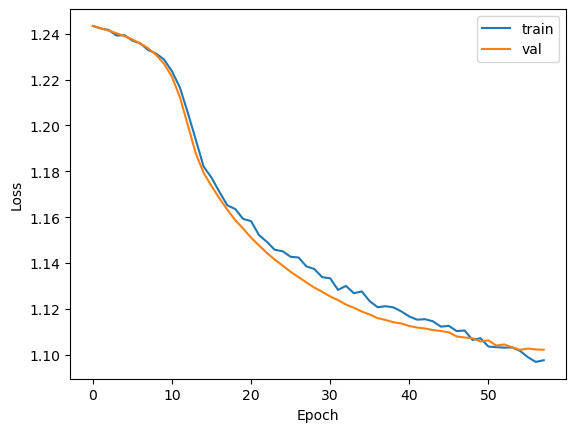

In [16]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [17]:
def evaluate_model(model, test_loader, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X, M, y in test_loader:
            X, M = X.to(device), M.to(device)
            p = model(X, M).squeeze(1).cpu().numpy()
            preds.append(p)
            labels.append(y.numpy())

    preds = np.concatenate(preds)
    labels = np.concatenate(labels)

    pred_bin = (preds >= 0.5).astype(int)
    acc = accuracy_score(labels, pred_bin)
    auc = roc_auc_score(labels, preds)
    prec = precision_score(labels, pred_bin, zero_division=0)
    rec = recall_score(labels, pred_bin)
    f1 = f1_score(labels, pred_bin)

    print("\nTest Metrics")
    print(f"Accuracy : {acc:.4f}")
    print(f"AUC      : {auc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return dict(acc=acc, auc=auc, precision=prec, recall=rec, f1=f1) , preds, labels

In [18]:
lstm_metrics, lstm_preds, labels = evaluate_model(lstm_model,test_loader)


Test Metrics
Accuracy : 0.7992
AUC      : 0.8156
Precision: 0.4219
Recall   : 0.6750
F1 Score : 0.5192


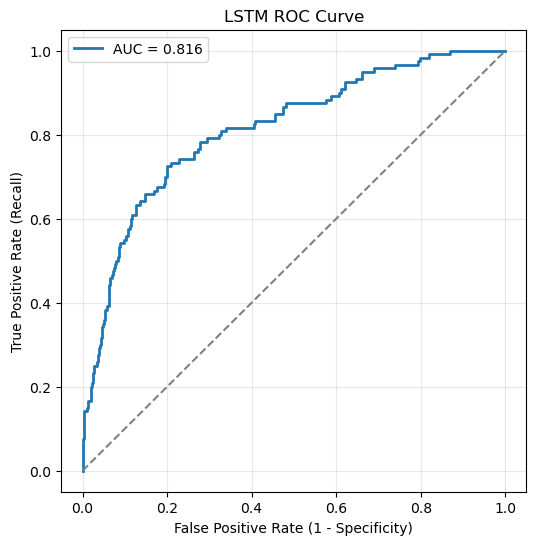

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(labels, lstm_preds)
auc = roc_auc_score(labels, lstm_preds)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('LSTM ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

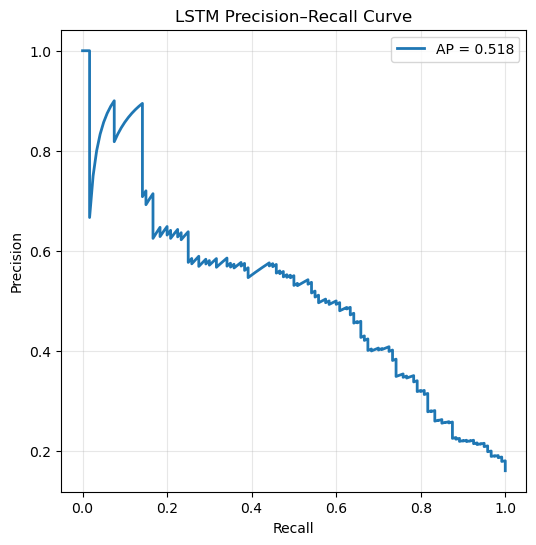

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, thr = precision_recall_curve(labels, lstm_preds)
ap = average_precision_score(labels, lstm_preds)
plt.figure(figsize=(6, 6))
plt.plot(rec, prec, label=f"AP = {ap:.3f}", linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('LSTM Precision–Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

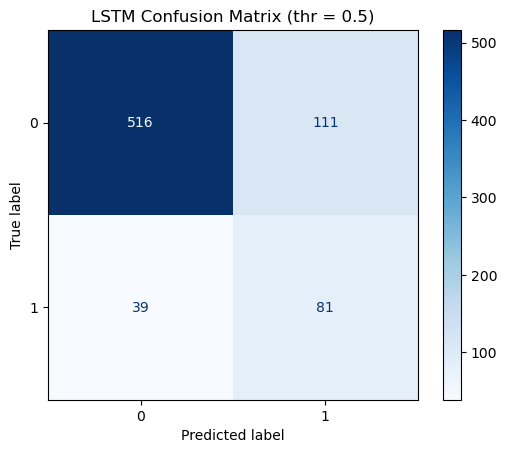

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
pred_bin = (lstm_preds >= 0.5).astype(int)
cm = confusion_matrix(labels, pred_bin)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.title('LSTM Confusion Matrix (thr = 0.5)')
plt.show()